In [55]:
import os
import pandas as pd
import seaborn as sns

# Define the DATA_DIRECTORY and FIGURE_DIRECTORY
HERE = os. getcwd()
DATA_DIRECTORY = os.path.abspath(os.path.join(HERE, os.pardir, 'data'))
FIGURE_DIRECTORY = os.path.abspath(os.path.join(HERE, os.pardir, 'figures'))

# 1. Dataset Difford


In [56]:
# Retrieve the ids of samples that has microbiome data

difford_taxa_path = os.path.join(DATA_DIRECTORY, 'processed','Difford2018', 'taxonomy', 'all_taxa_emission_reads_number.pkl' )
difford_tax_df = pd.read_pickle(difford_taxa_path)
difford_tax_df= difford_tax_df.sort_index()
difford_ids = difford_tax_df.index.values.tolist()


In [57]:
# loading the corresponding metadata data
difford_metadata_path = os.path.join(DATA_DIRECTORY, 'raw','Difford2018', 'emission_metadata.tsv' )
difford_metadata_df = pd.read_csv(difford_metadata_path, sep=' ', header=0)
difford_metadata_df= difford_metadata_df.sort_values(by=['sample_id'])

difford_metadata_df = difford_metadata_df.rename({"sample_id":"metadata_sample_id"}, axis=1)
difford_metadata_df = difford_metadata_df.set_index('metadata_sample_id')
difford_metadata_df = difford_metadata_df[difford_metadata_df.index.isin(difford_ids)]
difford_metadata_df

,Sequencing_Instrument,Sequencing_Batch,herd,Lactatation,days_in_milk,methane_grams_per_day
metadata_sample_id,,,,,,
01_J,2,8,5,1,73,520.00
02_J,2,8,5,2,67,568.00
03_J,2,8,5,1,157,628.00
04_J,2,8,5,1,45,559.00
05_J,2,8,5,1,9,498.00
06_J,2,9,5,1,10,503.00
07_J,2,9,5,2,75,600.00
08_J,2,9,5,1,75,586.00
09_J,2,9,5,2,94,605.00


In [58]:
sns.set(style='white')

def boxplot(metadata_df, column_name, by, ylabel, xlabel, dataset):
    bplot= metadata_df.boxplot(column=column_name, by=by, grid=False, figsize=[5,4])
    bplot.set_ylabel(ylabel)
    bplot.set_xlabel(xlabel)
    bplot.figure.tight_layout()
    bplot.figure.savefig(os.path.join(FIGURE_DIRECTORY, dataset+'_methane_emission_'+xlabel+'.png'))
    


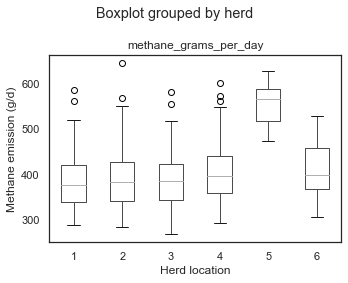

In [59]:
boxplot(difford_metadata_df, 'methane_grams_per_day', 'herd', 'Methane emission (g/d)', 'Herd location', 'difford')

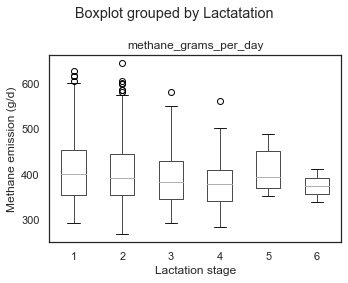

In [60]:
boxplot(difford_metadata_df, 'methane_grams_per_day', 'Lactatation', 'Methane emission (g/d)', 'Lactation stage', 'difford')


# 2. Dataset Wallace

In [69]:
# loading the corresponding metadata data
wallace_metadata_path = os.path.join(DATA_DIRECTORY, 'raw','Wallace2019', 'metadata.xlsx' )
wallace_metadata_df = pd.read_excel(wallace_metadata_path)
wallace_metadata_df= wallace_metadata_df.sort_values(by=['Cow Code']).dropna(axis=0,how='all').dropna(axis=0, subset=['methane g/d'])
wallace_metadata_df=wallace_metadata_df.loc[wallace_metadata_df['Holstein (1)/Nordic Red(2)'] == 1]
wallace_metadata_df.set_index('Cow Code', inplace=True)
wallace_metadata_df_dropna = wallace_metadata_df.dropna(how='any', axis=1)
wallace_metadata_df_dropna


,Country,Cow ID,Sampling week,Farm/Research site code,ear tag number,Holstein (1)/Nordic Red(2),Days in milk,Lactation number,"Live weight, kg",OM,...,Wolin,Ammonia,Measurement method,methane g/d,BHB,Urea,Cholesterol,Creatinine,Albumin,Haptoglobulin
Cow Code,,,,,,,,,,,,,,,,,,,,,
IT1007,IT,1007.0,2015-04-28 00:00:00,IT2,1747,1.0,140.0,2.0,820.000000,929.382000,...,342.292772,4.443120,GreenFeed,541.439752,1.481700,6.70230,5.750000,86.000000,35.135100,0.5574
IT1008,IT,1008.0,2015-04-28 00:00:00,IT2,1749,1.0,191.0,2.0,780.000000,929.382000,...,350.641191,2.192709,GreenFeed,712.719298,1.140700,6.64290,5.850000,86.000000,33.283800,0.1790
IT1009,IT,1009.0,2015-04-28 00:00:00,IT2,1795,1.0,162.0,2.0,800.000000,929.382000,...,339.788048,4.125754,GreenFeed,582.061333,1.577400,6.02910,5.110000,83.000000,36.729000,0.1704
IT1010,IT,1010.0,2015-04-28 00:00:00,IT2,1804,1.0,182.0,2.0,730.000000,929.382000,...,333.246407,4.760486,GreenFeed,545.326087,2.095500,5.55390,7.030000,87.000000,37.045800,0.1102
IT1011,IT,1011.0,2015-04-28 00:00:00,IT2,1806,1.0,161.0,2.0,735.000000,929.382000,...,321.217220,1.586829,GreenFeed,582.260317,0.885500,5.71230,8.030000,82.000000,34.164900,0.1016
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
UK95,UK,95.0,2014-02-10 00:00:00,UK1,306,1.0,90.0,2.0,556.166667,938.269725,...,340.850460,3.948218,Robot,414.624804,0.789886,5.77000,7.340265,85.004388,35.412008,0.1445
UK96,UK,96.0,2014-02-10 00:00:00,UK1,343,1.0,83.0,1.0,575.250000,938.269725,...,323.920660,5.334908,Robot,481.940186,0.623116,6.52473,6.448660,105.922152,37.989212,0.1235
UK97,UK,97.0,2014-02-10 00:00:00,UK1,353,1.0,102.0,1.0,572.178571,938.269725,...,326.851504,6.129571,Robot,418.275613,0.568180,4.07983,6.080795,88.506828,36.455162,0.1235


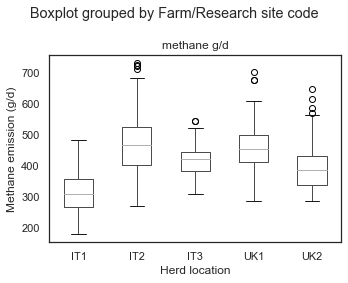

In [70]:
boxplot(wallace_metadata_df, 'methane g/d', 'Farm/Research site code', 'Methane emission (g/d)', 'Herd location', 'wallace')

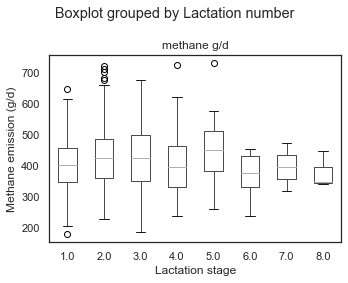

In [71]:
boxplot(wallace_metadata_df, 'methane g/d', 'Lactation number', 'Methane emission (g/d)', 'Lactation stage', 'wallace')